In [10]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
import torch
from torchvision import transforms
from PIL import Image

# 1. Setup Path ke Root Project & Folder Src
BASE_DIR = os.path.abspath(r"..\ ")
sys.path.append(os.path.join(BASE_DIR, "src"))

from models_eva import BiomassEVA02TargetQueryModel

# Path Data & Checkpoint
DATASET_DIR = os.path.join(BASE_DIR, r"data\csiro-biomass")
CSV_PATH = os.path.join(DATASET_DIR, "train_aug.csv")
IMG_DIR = os.path.join(DATASET_DIR, "Augmentation_data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Load Dataset
df = pd.read_csv(CSV_PATH)
target_cols = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
short_targets = ['Clover', 'Dead', 'Green', 'Total', 'GDM']

# Ensure Wide Format
if 'target_name' in df.columns:
    df = df.pivot(index='image_path', columns='target_name', values='target').reset_index()
    df.columns.name = None

# Ekstrak ID Gambar Asli (Group ID) untuk Mencegah Kebocoran Data Augmentasi
def extract_base_id(fname):
    base = os.path.basename(str(fname)).split('.')[0]
    # Menghapus suffix augmentasi (_clahe, _rot90, _sharp, dll)
    for suffix in ['_clahe', '_sharp', '_color', '_rot90', '_rot180', '_rot270', '_hflip', '_vflip']:
        base = base.replace(suffix, '')
    return base

df['group_id'] = df['image_path'].apply(extract_base_id)

print(f"✓ Total Sampel Data Wide Format : {len(df)}")
print(f"✓ Total Gambar Asli Unik (Groups): {df['group_id'].nunique()}")

✓ Total Sampel Data Wide Format : 3570
✓ Total Gambar Asli Unik (Groups): 357


In [11]:
# Setup 5-Fold Group Cross Validation
gkf = GroupKFold(n_splits=5)
df['fold'] = -1

for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(df, groups=df['group_id'])):
    df.loc[val_idx, 'fold'] = fold_idx

# Device Setup & Model Initialization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights_path = os.path.join(OUTPUT_DIR, "best_biomass_eva02_model.pth")

model = BiomassEVA02TargetQueryModel(model_name='eva02_tiny_patch14_224', pretrained=False)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Matriks Penyimpan Hasil Prediksi & Evaluasi
fold_r2_matrix = []
oof_preds = np.zeros((len(df), 5))
oof_targets = df[target_cols].values

print("\n--- Memulai Evaluasi 5-Fold Cross Validation ---")

for fold in range(5):
    val_subset = df[df['fold'] == fold].reset_index(drop=True)
    val_indices = df[df['fold'] == fold].index
    
    preds_list = []
    
    for _, row in val_subset.iterrows():
        fname = os.path.basename(str(row['image_path']))
        actual_path = os.path.join(IMG_DIR, fname)
        
        if not os.path.exists(actual_path):
            actual_path = os.path.join(DATASET_DIR, "train_images", fname)
            
        img_pil = Image.open(actual_path).convert('RGB')
        t_img = val_transform(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred = model(t_img).cpu().numpy()[0]
            pred = np.clip(pred, a_min=0.0, a_max=None)
            preds_list.append(pred)
            
    preds_arr = np.array(preds_list)
    oof_preds[val_indices] = preds_arr
    
    # Hitung R2 Score Per-Target untuk Fold ini
    targets_arr = val_subset[target_cols].values
    r2_targets = r2_score(targets_arr, preds_arr, multioutput='raw_values')
    mean_fold_r2 = float(np.mean(r2_targets))
    
    fold_r2_matrix.append([mean_fold_r2] + list(r2_targets))
    print(f"Fold {fold+1} | Mean R²: {mean_fold_r2:.4f} | Target R²: {[round(x, 4) for x in r2_targets]}")

# Format ke DataFrame
cols_r2_df = ['Mean_R2'] + [f"R2_{t}" for t in short_targets]
df_r2_summary = pd.DataFrame(fold_r2_matrix, columns=cols_r2_df, index=[f"Fold {i+1}" for i in range(5)])

# Hitung Total Out-Of-Fold (OOF) R2 Score
overall_oof_r2_per_target = r2_score(oof_targets, oof_preds, multioutput='raw_values')
overall_oof_mean_r2 = float(np.mean(overall_oof_r2_per_target))

# Tambahkan Baris Total OOF ke Tabel
df_r2_summary.loc['Overall OOF'] = [overall_oof_mean_r2] + list(overall_oof_r2_per_target)

print("\n" + "="*80)
print("📊 TABEL EVALUASI R² SCORE PER TARGET PER FOLD")
print("="*80)
print(df_r2_summary.round(4))


--- Memulai Evaluasi 5-Fold Cross Validation ---
Fold 1 | Mean R²: 0.9952 | Target R²: [np.float64(0.9893), np.float64(0.9953), np.float64(0.9977), np.float64(0.9963), np.float64(0.9975)]
Fold 2 | Mean R²: 0.9970 | Target R²: [np.float64(0.9975), np.float64(0.9935), np.float64(0.9984), np.float64(0.9973), np.float64(0.9984)]
Fold 3 | Mean R²: 0.9956 | Target R²: [np.float64(0.9955), np.float64(0.9926), np.float64(0.9969), np.float64(0.9965), np.float64(0.9964)]
Fold 4 | Mean R²: 0.9897 | Target R²: [np.float64(0.998), np.float64(0.9624), np.float64(0.9967), np.float64(0.995), np.float64(0.9964)]
Fold 5 | Mean R²: 0.9860 | Target R²: [np.float64(0.997), np.float64(0.9872), np.float64(0.9787), np.float64(0.9888), np.float64(0.9785)]

📊 TABEL EVALUASI R² SCORE PER TARGET PER FOLD
             Mean_R2  R2_Clover  R2_Dead  R2_Green  R2_Total  R2_GDM
Fold 1        0.9952     0.9893   0.9953    0.9977    0.9963  0.9975
Fold 2        0.9970     0.9975   0.9935    0.9984    0.9973  0.9984
Fold

<Figure size 1400x600 with 0 Axes>

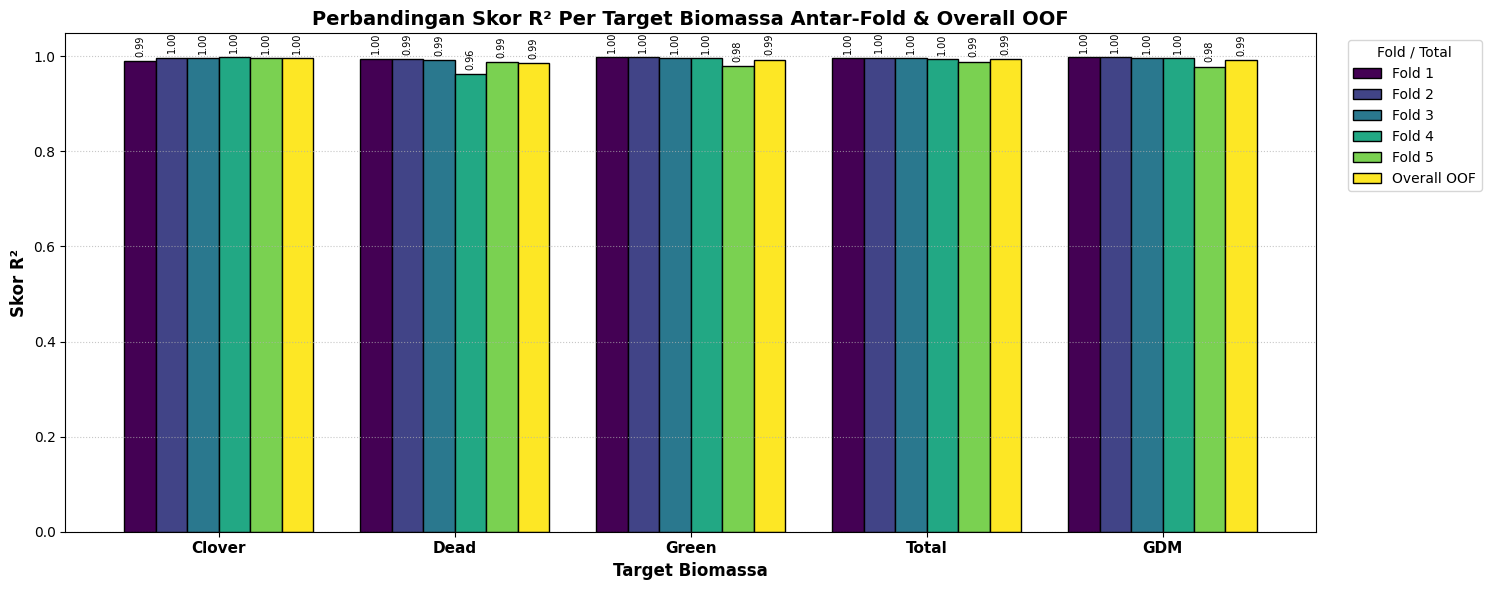

In [12]:
# Visualisasi Barplot R2 Score Per Target Per Fold
plt.figure(figsize=(14, 6))

r2_plot_data = df_r2_summary.iloc[:5, 1:].T
r2_plot_data.columns = [f"Fold {i+1}" for i in range(5)]
r2_plot_data['Overall OOF'] = df_r2_summary.loc['Overall OOF', 'R2_Clover':].values

ax = r2_plot_data.plot(kind='bar', figsize=(15, 6), colormap='viridis', edgecolor='black', width=0.8)

plt.title("Perbandingan Skor R² Per Target Biomassa Antar-Fold & Overall OOF", fontsize=14, fontweight='bold')
plt.xlabel("Target Biomassa", fontsize=12, fontweight='bold')
plt.ylabel("Skor R²", fontsize=12, fontweight='bold')
plt.xticks(ticks=range(5), labels=short_targets, rotation=0, fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title="Fold / Total", bbox_to_anchor=(1.02, 1), loc='upper left')

# Tambahkan Label Nilai di Atas Bar
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f"{height:.2f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=7, rotation=90, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "r2_score_per_target_folds.png"), dpi=200)
plt.show()

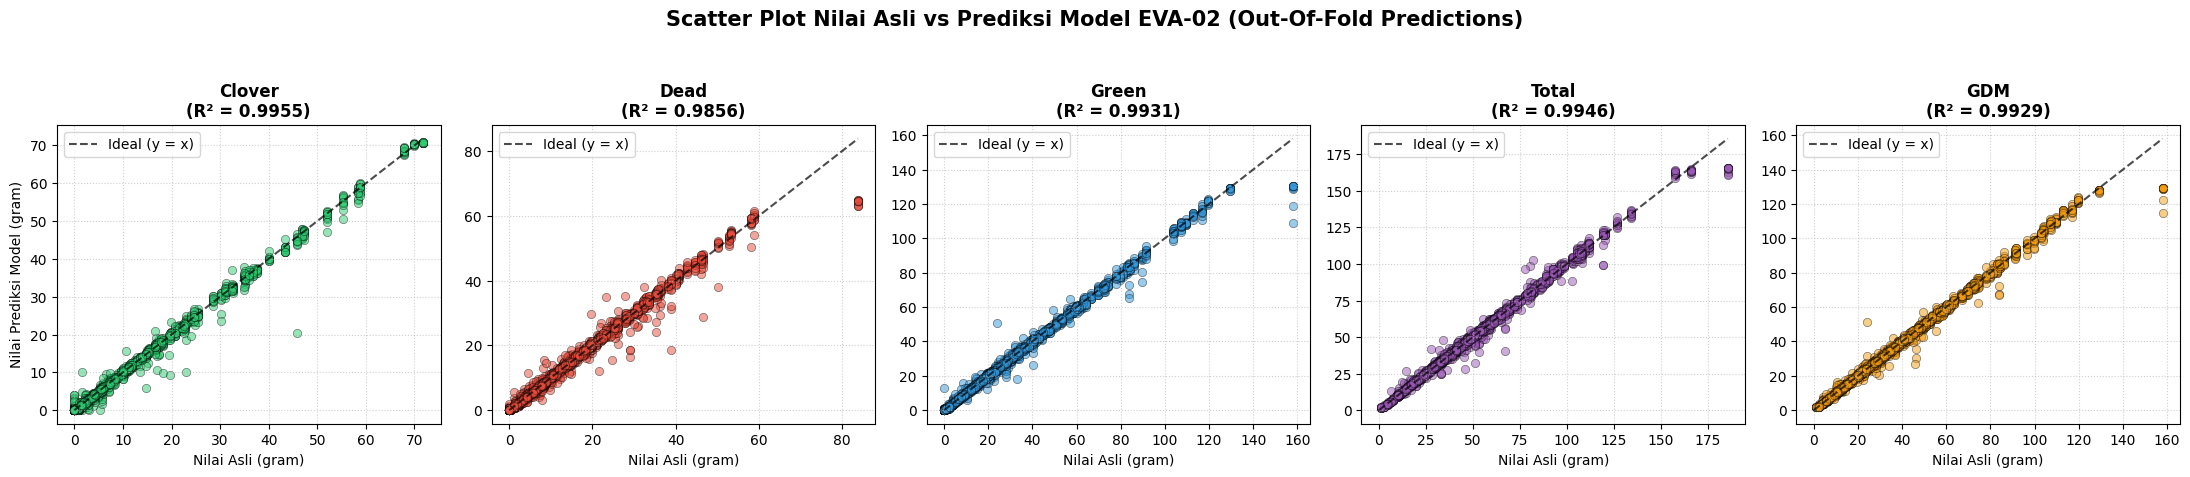

In [13]:
# Visualisasi Scatter Plot Actual vs Predicted untuk 5 Target (Overall OOF)
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

for idx, target in enumerate(target_cols):
    ax = axes[idx]
    y_true = oof_targets[:, idx]
    y_pred = oof_preds[:, idx]
    r2_val = overall_oof_r2_per_target[idx]
    
    # Scatter Plot
    ax.scatter(y_true, y_pred, alpha=0.5, color=colors[idx], edgecolors='k', linewidth=0.5)
    
    # Garis Regresi Ideal y = x
    max_val = max(np.max(y_true), np.max(y_pred))
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='Ideal (y = x)')
    
    ax.set_title(f"{short_targets[idx]}\n(R² = {r2_val:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Nilai Asli (gram)", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Nilai Prediksi Model (gram)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

plt.suptitle("Scatter Plot Nilai Asli vs Prediksi Model EVA-02 (Out-Of-Fold Predictions)", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "oof_actual_vs_predicted_scatter.png"), dpi=200)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_5884\177318193.py:116: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches='tight')
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


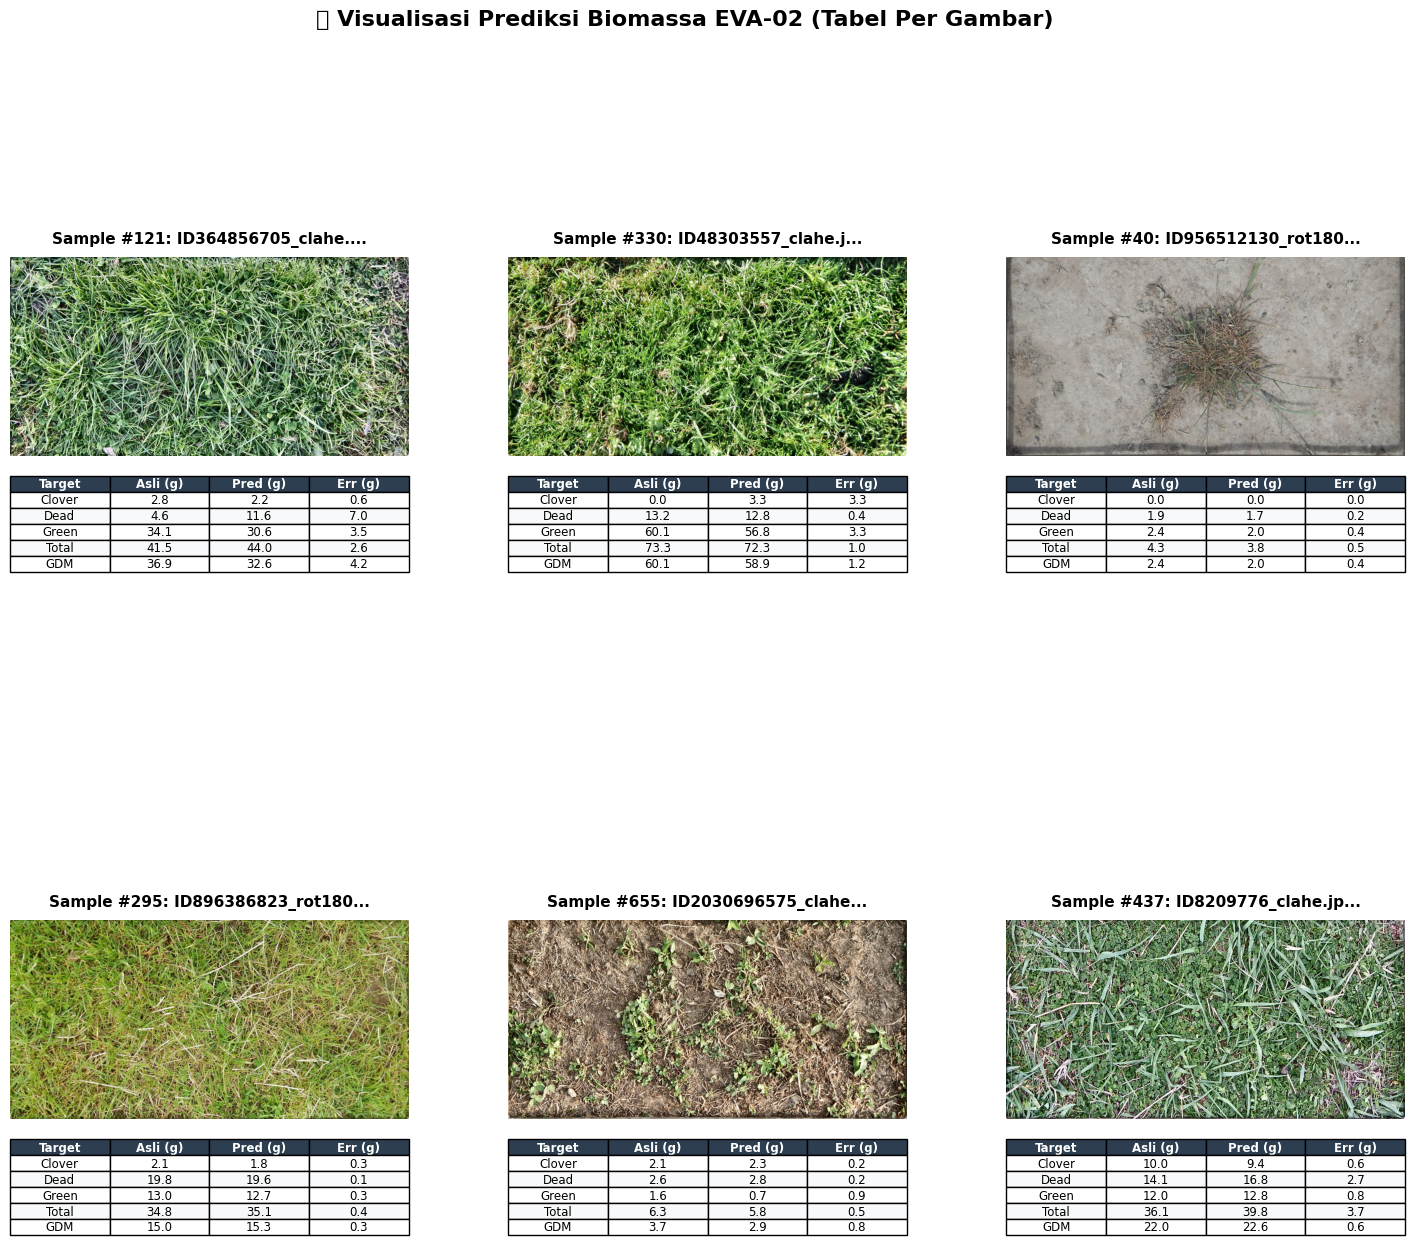

✓ Visualisasi berhasil disimpan di: 'd:\-\GEMASTIK 8\outputs\visualisasi_6_gambar_tabel.png'


In [14]:
from sklearn.model_selection import train_test_split
# -------------------------------------------------------------
# 1. SETUP PATH & MEMUAT MODEL EVA-02 TERBARU
# -------------------------------------------------------------
DATA_DIR = os.path.join(BASE_DIR, "data", "csiro-biomass")
CSV_PATH = os.path.join(DATA_DIR, "train_aug.csv")
IMG_DIR = os.path.join(DATASET_DIR if 'DATASET_DIR' in locals() else DATA_DIR, "Augmentation_data")

MODEL_PATH = os.path.join(BASE_DIR, "outputs", "best_biomass_eva02_model.pth")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Dataset CSV & Split Validation
df_full = pd.read_csv(CSV_PATH)
if 'target_name' in df_full.columns:
    df_full = df_full.pivot(index='image_path', columns='target_name', values='target').reset_index()
    df_full.columns.name = None

_, val_df = train_test_split(df_full, test_size=0.20, random_state=42)
val_df = val_df.reset_index(drop=True)

# Transformasi Validasi
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Model
model = BiomassEVA02TargetQueryModel(model_name='eva02_tiny_patch14_224', pretrained=False)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

target_names = ['Clover', 'Dead', 'Green', 'Total', 'GDM']
target_cols = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']

# -------------------------------------------------------------
# 2. FUNGSI VISUALISASI GAMBAR + TABEL TERINTEGRASI
# -------------------------------------------------------------
def visualize_6_images_with_embedded_tables(val_df, model, num_images=6):
    np.random.seed(42)
    sample_indices = np.random.choice(len(val_df), size=num_images, replace=False)
    
    # Ukuran Figure disesuaikan tinggi (height=14) agar tabel muat dengan rapi di bawah gambar
    fig, axes = plt.subplots(2, 3, figsize=(18, 14))
    axes = axes.flatten()
    
    col_labels = ['Target', 'Asli (g)', 'Pred (g)', 'Err (g)']
    
    for i, idx in enumerate(sample_indices):
        ax = axes[i]
        row = val_df.iloc[idx]
        
        # Nama & Path Gambar
        img_col = 'image_path' if 'image_path' in row else val_df.columns[0]
        raw_img_name = str(row[img_col])
        fname = os.path.basename(raw_img_name)
        
        img_path = os.path.join(IMG_DIR, fname)
        if not os.path.exists(img_path):
            img_path = os.path.join(DATA_DIR, "train_images", fname)
            
        raw_img = Image.open(img_path).convert("RGB")
        
        # Predict
        tensor_img = val_transform(raw_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(tensor_img).cpu().numpy()[0]
            pred_g = np.clip(output, a_min=0.0, a_max=None)
            
        actual_g = row[target_cols].values.astype(float)
        
        # Plot Gambar
        ax.imshow(raw_img)
        ax.set_title(f"Sample #{idx+1}: {fname[:18]}...", fontsize=11, fontweight='bold', pad=10)
        ax.axis('off')
        
        # Data untuk Tabel dalam Gambar
        cell_text = []
        for t_idx, t_name in enumerate(target_names):
            act_v = actual_g[t_idx]
            prd_v = pred_g[t_idx]
            err_v = abs(act_v - prd_v)
            cell_text.append([t_name, f"{act_v:.1f}", f"{prd_v:.1f}", f"{err_v:.1f}"])
            
        # Buat Tabel Matplotlib di bawah Subplot Gambar
        table = ax.table(
            cellText=cell_text,
            colLabels=col_labels,
            loc='bottom',
            cellLoc='center',
            bbox=[0.0, -0.58, 1.0, 0.48]  # [left, bottom, width, height] relatif terhadap ax
        )
        
        # Styling Tabel (Header Gelap, Font Bersih, Warna Baris Selang-Seling)
        table.auto_set_font_size(False)
        table.set_fontsize(8.5)
        
        for (row_idx, col_idx), cell in table.get_celld().items():
            if row_idx == 0:
                cell.set_text_props(weight='bold', color='white')
                cell.set_facecolor('#2c3e50')  # Header Navy
            else:
                if row_idx % 2 == 0:
                    cell.set_facecolor('#f8f9fa')  # Abu-abu muda
                else:
                    cell.set_facecolor('#ffffff')  # Putih

    plt.suptitle("📸 Visualisasi Prediksi Biomassa EVA-02 (Tabel Per Gambar)", fontsize=16, fontweight='bold', y=0.98)
    
    # Berikan jarak vertikal antar baris agar tabel tidak bertabrakan dengan judul gambar di bawahnya
    plt.subplots_adjust(hspace=0.6, wspace=0.25)
    
    # Simpan Gambar Hasil
    save_path = os.path.join(BASE_DIR, "outputs", "visualisasi_6_gambar_tabel.png")
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Visualisasi berhasil disimpan di: '{save_path}'")

# Jalankan Visualisasi
visualize_6_images_with_embedded_tables(val_df, model, num_images=6)